In [1]:
%load_ext autoreload
%autoreload 2
from FIFOv4 import FIFO 
import matplotlib.pyplot as plt
import numpy as np
import math
from spcm import units
import spcm as spcm
import time as time
from time import sleep 
# import API classes into the current namespace
from pulsestreamer import PulseStreamer, Sequence 
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
# Coself.samplesself.samplesect to Pulse Streamer
ip = '10.135.70.193' 
ps = PulseStreamer(ip)

Connect to Pulse Streamer via JSON-RPC.
IP / Hostname: 10.135.70.193
Pulse Streamer 8/2 firmware: v1.5.2
Client software: v1.7.0
Your client software is more up to date than the Pulse Streamer 8/2 firmware. We recommend updating the firmware of your Pulse Streamer 8/2.
For detailed information visit https://www.swabianinstruments.com/pulse-streamer-8-2/downloads/ or contact support@swabianinstruments.com


In [3]:
ps.reset()

0

In [4]:
seq1=ps.createSequence()

In [5]:
# creating the arbitrary wave to measure
pattern=[(200,0),(300,1),(3000-200-200-100,0)]#,(300,1),(500,0),(400,1),(500,0),(10000000000,0),(500,1),(100,0)]
# seq1.setAnalog(0,pattern)
seq1.setDigital(5,pattern)
# create the trigger signal -- square wave 

pattern_trigger=[(100,1),(100,0), (3000-100-100,0)] #,(500,0.5),(700,0),(100,1.6),(10,0),(10000000000,0),(500,1),(100,0)]

seq1.setDigital(1,pattern_trigger) # assing the trigger to the same sequence as the simulated wave
# seq1.setAnalog(0,pattern)

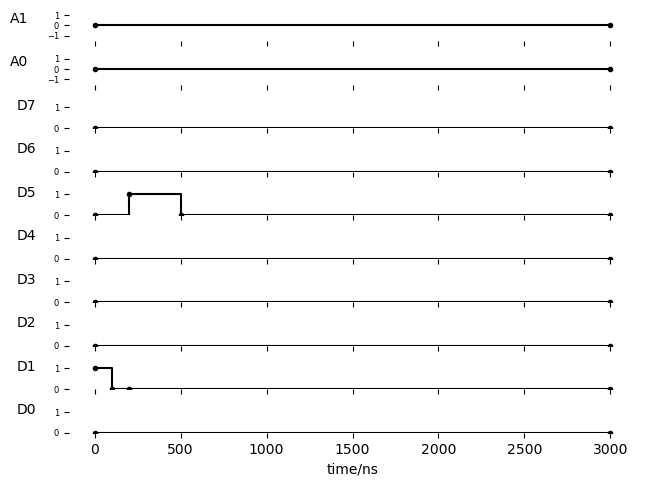

In [6]:
seq1.plot()

In [7]:
# Creating an instance of the digiziter class
# You are required to pass the IP address of the digitizer 
# If the IP changes, you can find it in the spectrum controls app on the desktop

FIFO = FIFO('dev/spcm0')

# Creating an instance of the class will call the connect function 
# and establish the connection with the digitizer 
# If the connection is unsuccessful, it will print, "Connection unsuccessful"

Successfully connected to the digitizer


In [8]:
# To set the configuration, make a dictionary with the key and value
num_iters=12
config1={'num_samples' :None,
         'runs': 4,
         'readout_ch' :0,
         'num_pts_in_exp':2,
         'num_iters':num_iters}

In [9]:
# Assign_param takes the configuration and gives it to the class dictionary 

FIFO.assign_param(config1)

In [10]:
FIFO.config()

SETTINGS: card timeout =  20 s
SETTINGS: # segments =  512 Sa
SETTINGS: sampling freq =  0.5 GHz
SETTINGS: pretrig size =  32 Sa
SETTINGS: termination =  1
3101 8
1126
8192
50 ohm impedance? 1


In [11]:
n_runs = PulseStreamer.REPEAT_INFINITELY
ps.stream(seq1, n_runs)


In [12]:
for i in range(1,4):
    print(i)

1
2
3


In [13]:
FIFO.config()
FIFO.start_buffer()

archive=[]

for i in range(2):
    temp=list(FIFO.acquire())
    archive+=temp
    # plt.plot(archive)

FIFO.stop_card()
FIFO.reset()
ps.reset()


SETTINGS: card timeout =  20 s
SETTINGS: # segments =  512 Sa
SETTINGS: sampling freq =  0.5 GHz
SETTINGS: pretrig size =  32 Sa
SETTINGS: termination =  1
3101 8
1126
8192
50 ohm impedance? 1
(8, 512, 1)
termination setting: 1 1/Sa
(6, 512, 1)
termination setting: 1 1/Sa
Card stopped


0

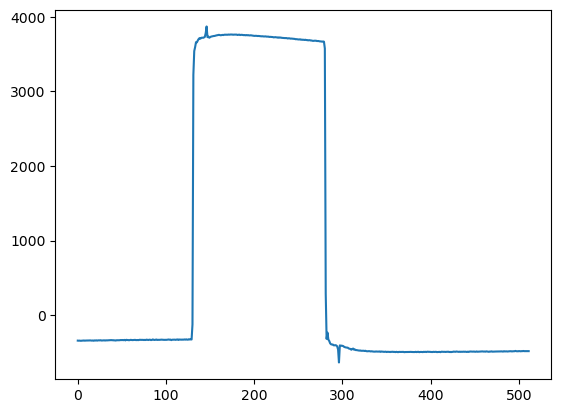

In [14]:

plt.plot(FIFO.raw_data[0])


-334.94


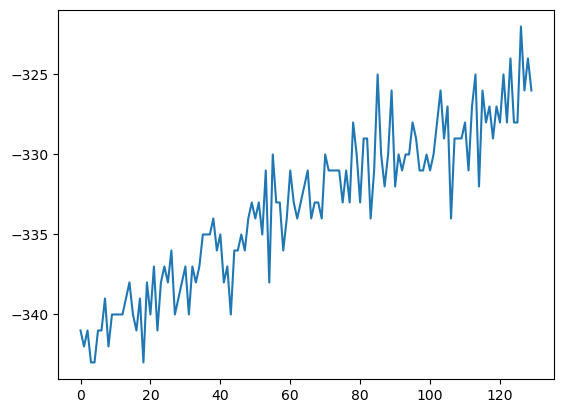

In [15]:
plt.plot(FIFO.raw_data[0][0:130])
print(np.mean(FIFO.raw_data[0][0:100]))

3758.9


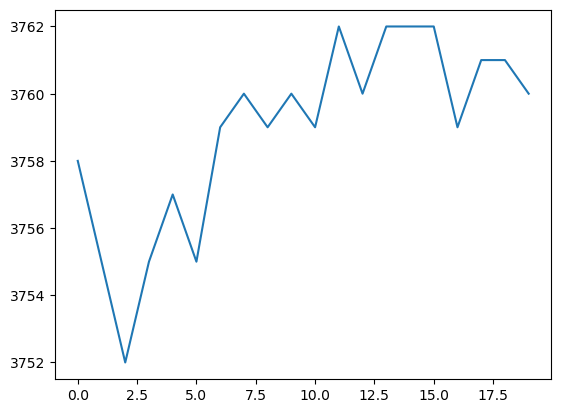

In [16]:
plt.plot(FIFO.raw_data[0][160:180])
print(np.mean(FIFO.raw_data[0][160:180]))

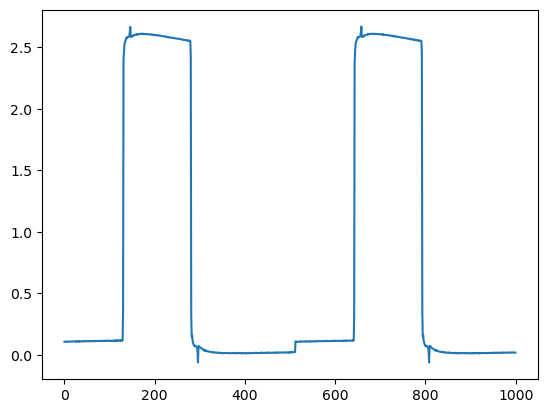

In [17]:
plt.plot(np.ravel(archive)[0:1000])

0.10961157226562504


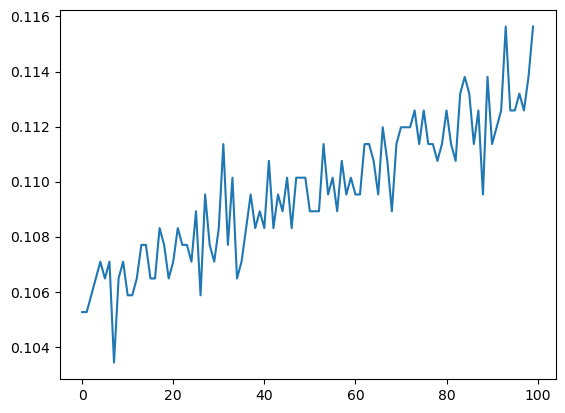

In [18]:
plt.plot(np.ravel(archive)[0:100])
print(np.mean(np.ravel(archive)[0:100]))

2.6036881103515626


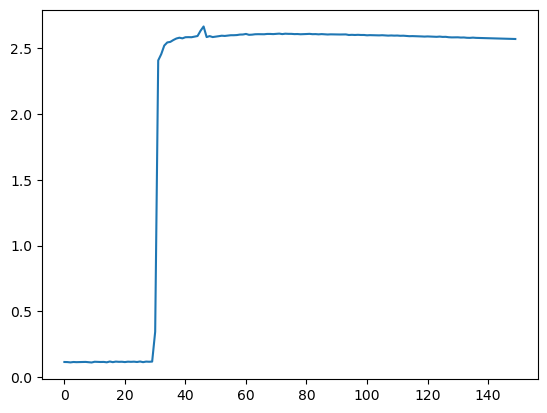

In [19]:
plt.plot(np.ravel(archive)[100:250])
print(np.mean(np.ravel(archive)[140:180]))

In [20]:
np.min(np.ravel(archive))

-0.0815078125

In [21]:
np.max(np.ravel(archive))

2.68948828125

In [22]:
2.2907+.204248046875

2.4949480468750003

In [23]:
2.50


2.5

In [24]:
2.6-2.2907257080078125

0.3092742919921876